<a href="https://colab.research.google.com/github/febriyanaft/End-to-End-NLP-Analisis-Sentimen-Topik-SNBP/blob/main/UTS_Praktik_ATMS_AF_%5B2412501591%5D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# UTS Praktik ATMS [AF] – End-to-End NLP Pipeline

# Febriyana Triwijayanti (2412501591)

In [ ]:
# @title Import Library
# INSTALL =====
!pip install gensim
!pip install Sastrawi
!pip install nltk
!pip install wordcloud

# BASIC =====
import pandas as pd
import numpy as np
import re

# NLP =====
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
import nltk
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('vader_lexicon')
nltk.download('punkt_tab')
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# SENTIMENT =====
from nltk.sentiment import SentimentIntensityAnalyzer

# STEMMING =====
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

# WORD2VEC =====
from gensim.models import Word2Vec

# VISUALIZATION =====
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 29.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 7.9 MB/s eta 0:00:00


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [ ]:
# @title Load Data
df = pd.read_csv('snbp.csv')
df.head(10)

,conversation_id_str,created_at,favorite_count,full_text,id_str,image_url,in_reply_to_screen_name,lang,location,quote_count,reply_count,retweet_count,tweet_url,user_id_str,username
0,2038891259851624874,Tue Mar 31 08:08:51 +0000 2026,7251,Alhamdulillah ya Allah aku lulus SNBP https://...,2038891259851624874,https://pbs.twimg.com/media/HEuYy7qboAAmSBF.jpg,NaN,in,NaN,259,195,813,https://x.com/undefined/status/203889125985162...,1497532494933262337,NaN
1,2038907937909813573,Tue Mar 31 09:15:08 +0000 2026,6155,Sch! TOLONGG KASIH TIPS BELAJAR UTBK DARI 0 DI...,2038907937909813573,NaN,NaN,in,NaN,29,79,700,https://x.com/undefined/status/203890793790981...,1201673806156161025,NaN
2,2038900509667672248,Tue Mar 31 08:45:37 +0000 2026,7995,tahun lalu aku juga dapet merah di SNBP 2025 t...,2038900509667672248,https://pbs.twimg.com/media/HEuhNOsawAABR5j.jpg,NaN,in,NaN,24,636,649,https://x.com/undefined/status/203890050966767...,1280296297270882304,NaN
3,2038831758125478317,Tue Mar 31 04:12:25 +0000 2026,12911,adek adek snbp unpad 2026 kalo pengumumannya d...,2038831758125478317,https://pbs.twimg.com/media/HEtirNhakAA-oGc.jpg,NaN,in,NaN,228,118,392,https://x.com/undefined/status/203883175812547...,1723611153191014400,NaN
4,2038913740226388414,Tue Mar 31 09:38:11 +0000 2026,4914,️ dari SD OSN gagal terus ️ gagal lomba yang l...,2038913740226388414,https://pbs.twimg.com/media/HEutPe4bYAA9qFe.jpg,NaN,in,NaN,103,79,426,https://x.com/undefined/status/203891374022638...,1413702254251577346,NaN
5,2038889715169218774,Tue Mar 31 08:02:43 +0000 2026,18302,demi apa sih lolos snbp stei-k itb ⁉️ #snbp202...,2038889715169218774,https://pbs.twimg.com/media/HEuXY6rasAAvOQG.jpg,NaN,in,NaN,246,708,612,https://x.com/undefined/status/203888971516921...,1610973894974001155,NaN
6,2038892446084653366,Tue Mar 31 08:13:34 +0000 2026,25113,ALHAMDULILLAHHHH JADI PEMBUKA BUAT DEKEL ITUUU...,2038892446084653366,https://pbs.twimg.com/media/HEuZ3yWagAA7WF_.jpg,NaN,in,NaN,492,369,880,https://x.com/undefined/status/203889244608465...,1749416269055741952,NaN
7,2040410623532810579,Sat Apr 04 12:46:16 +0000 2026,8122,emg snbp tuh ghaib bgt yh... di sekolah gw eli...,2040410623532810579,NaN,NaN,in,NaN,189,155,91,https://x.com/undefined/status/204041062353281...,1542975110856187904,NaN
8,2038889582293582083,Tue Mar 31 08:02:11 +0000 2026,6175,alhamdulillah furab lolos snbp https://t.co/Ao...,2038889582293582083,https://pbs.twimg.com/media/HEuXRGEbsAAPn_U.jpg,NaN,in,NaN,163,156,954,https://x.com/undefined/status/203888958229358...,1763208453110067208,NaN
9,2038890162718220777,Tue Mar 31 08:04:30 +0000 2026,7214,GUYS AKU LOLOS TEKKIM UNDIPPP https://t.co/LdY...,2038890162718220777,https://pbs.twimg.com/media/HEuXyynawAAZGKO.jpg,NaN,in,NaN,33,404,256,https://x.com/undefined/status/203889016271822...,1693437971469570048,NaN


In [ ]:
# @title Data Understanding

# Tampilkan 5 data awal
print("=== 5 Data Awal ===")
display(df.head())

print(df.info())
print(df.columns)

# Cek isi kolom teks
df['full_text'].head(5)

=== 5 Data Awal ===


,conversation_id_str,created_at,favorite_count,full_text,id_str,image_url,in_reply_to_screen_name,lang,location,quote_count,reply_count,retweet_count,tweet_url,user_id_str,username
0,2038891259851624874,Tue Mar 31 08:08:51 +0000 2026,7251,Alhamdulillah ya Allah aku lulus SNBP https://...,2038891259851624874,https://pbs.twimg.com/media/HEuYy7qboAAmSBF.jpg,NaN,in,NaN,259,195,813,https://x.com/undefined/status/203889125985162...,1497532494933262337,NaN
1,2038907937909813573,Tue Mar 31 09:15:08 +0000 2026,6155,Sch! TOLONGG KASIH TIPS BELAJAR UTBK DARI 0 DI...,2038907937909813573,NaN,NaN,in,NaN,29,79,700,https://x.com/undefined/status/203890793790981...,1201673806156161025,NaN
2,2038900509667672248,Tue Mar 31 08:45:37 +0000 2026,7995,tahun lalu aku juga dapet merah di SNBP 2025 t...,2038900509667672248,https://pbs.twimg.com/media/HEuhNOsawAABR5j.jpg,NaN,in,NaN,24,636,649,https://x.com/undefined/status/203890050966767...,1280296297270882304,NaN
3,2038831758125478317,Tue Mar 31 04:12:25 +0000 2026,12911,adek adek snbp unpad 2026 kalo pengumumannya d...,2038831758125478317,https://pbs.twimg.com/media/HEtirNhakAA-oGc.jpg,NaN,in,NaN,228,118,392,https://x.com/undefined/status/203883175812547...,1723611153191014400,NaN
4,2038913740226388414,Tue Mar 31 09:38:11 +0000 2026,4914,️ dari SD OSN gagal terus ️ gagal lomba yang l...,2038913740226388414,https://pbs.twimg.com/media/HEutPe4bYAA9qFe.jpg,NaN,in,NaN,103,79,426,https://x.com/undefined/status/203891374022638...,1413702254251577346,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114 entries, 0 to 113
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   conversation_id_str      114 non-null    int64  
 1   created_at               114 non-null    object 
 2   favorite_count           114 non-null    int64  
 3   full_text                114 non-null    object 
 4   id_str                   114 non-null    int64  
 5   image_url                59 non-null     object 
 6   in_reply_to_screen_name  1 non-null      object 
 7   lang                     114 non-null    object 
 8   location                 0 non-null      float64
 9   quote_count              114 non-null    int64  
 10  reply_count              114 non-null    int64  
 11  retweet_count            114 non-null    int64  
 12  tweet_url                114 non-null    object 
 13  user_id_str              114 non-null    int64  
 14  username                 0

,full_text
0,Alhamdulillah ya Allah aku lulus SNBP https://...
1,Sch! TOLONGG KASIH TIPS BELAJAR UTBK DARI 0 DI...
2,tahun lalu aku juga dapet merah di SNBP 2025 t...
3,adek adek snbp unpad 2026 kalo pengumumannya d...
4,️ dari SD OSN gagal terus ️ gagal lomba yang l...


In [ ]:
df[['full_text','clean_text']].head(5)

,full_text,clean_text
0,Alhamdulillah ya Allah aku lulus SNBP https://...,alhamdulillah ya allah aku lulus snbp
1,Sch! TOLONGG KASIH TIPS BELAJAR UTBK DARI 0 DI...,sch tolongg kasih tips belajar utbk dari di h...
2,tahun lalu aku juga dapet merah di SNBP 2025 t...,tahun lalu aku juga dapet merah di snbp tapi ...
3,adek adek snbp unpad 2026 kalo pengumumannya d...,adek adek snbp unpad kalo pengumumannya delay...
4,️ dari SD OSN gagal terus ️ gagal lomba yang l...,dari sd osn gagal terus gagal lomba yang lai...


In [ ]:
# @title Preprocessing (advance)

# ===== Case Folding
df['clean_text'] = df['full_text'].str.lower()

# ===== Cleaning
def cleaning(text):
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return text

df['clean_text'] = df['clean_text'].apply(cleaning)

# ===== Tokenizing
df['tokenized_text'] = df['clean_text'].apply(word_tokenize)

# ===== Stopword Removal
stop_words = set(stopwords.words('indonesian'))
df['filtered_text'] = df['tokenized_text'].apply(lambda x: [word for word in x if word not in stop_words])

# ===== Normalisasi
normalisasi_words = {
    'yg': 'yang', 'dgn': 'dengan', 'utk': 'untuk', 'udh': 'sudah', 'gak': 'tidak',
    'ga': 'tidak', 'jg': 'juga', 'aja': 'saja', 'bgt': 'banget', 'bbrp': 'beberapa',
    'tpi': 'tapi', 'tdk': 'tidak', 'sdh': 'sudah', 'sy': 'saya', 'brp': 'berapa',
    'klo': 'kalau', 'kpn': 'kapan', 'mksh': 'terima kasih', 'makasih': 'terima kasih',
    'sbnrnya': 'sebenarnya', 'bgmn': 'bagaimana', 'gt': 'begitu', 'udah': 'sudah'
}

def normalize_text(text):
    return [normalisasi_words.get(word, word) for word in text]

df['normalized_text'] = df['filtered_text'].apply(normalize_text)

# ===== Stemming
factory = StemmerFactory()
stemmer = factory.create_stemmer()

def stem_text(text_list):
    return [stemmer.stem(word) for word in text_list]

df['stemmed_text'] = df['normalized_text'].apply(stem_text)
df[['full_text', 'clean_text', 'tokenized_text', 'filtered_text', 'normalized_text', 'stemmed_text']].head()

,full_text,clean_text,tokenized_text,filtered_text,normalized_text,stemmed_text
0,Alhamdulillah ya Allah aku lulus SNBP https://...,alhamdulillah ya allah aku lulus snbp,"[alhamdulillah, ya, allah, aku, lulus, snbp]","[alhamdulillah, ya, allah, lulus, snbp]","[alhamdulillah, ya, allah, lulus, snbp]","[alhamdulillah, ya, allah, lulus, snbp]"
1,Sch! TOLONGG KASIH TIPS BELAJAR UTBK DARI 0 DI...,sch tolongg kasih tips belajar utbk dari di h...,"[sch, tolongg, kasih, tips, belajar, utbk, dar...","[sch, tolongg, kasih, tips, belajar, utbk, h, ...","[sch, tolongg, kasih, tips, belajar, utbk, h, ...","[sch, tolongg, kasih, tips, ajar, utbk, h, gin..."
2,tahun lalu aku juga dapet merah di SNBP 2025 t...,tahun lalu aku juga dapet merah di snbp tapi ...,"[tahun, lalu, aku, juga, dapet, merah, di, snb...","[dapet, merah, snbp, berhasil, lolos, snbt, be...","[dapet, merah, snbp, berhasil, lolos, snbt, be...","[dapet, merah, snbp, hasil, lolos, snbt, ajar,..."
3,adek adek snbp unpad 2026 kalo pengumumannya d...,adek adek snbp unpad kalo pengumumannya delay...,"[adek, adek, snbp, unpad, kalo, pengumumannya,...","[adek, adek, snbp, unpad, kalo, pengumumannya,...","[adek, adek, snbp, unpad, kalo, pengumumannya,...","[adek, adek, snbp, unpad, kalo, umum, delay, r..."
4,️ dari SD OSN gagal terus ️ gagal lomba yang l...,dari sd osn gagal terus gagal lomba yang lai...,"[dari, sd, osn, gagal, terus, gagal, lomba, ya...","[sd, osn, gagal, gagal, lomba, gagal, ptln, ga...","[sd, osn, gagal, gagal, lomba, gagal, ptln, ga...","[sd, osn, gagal, gagal, lomba, gagal, ptln, ga..."


In [ ]:
# ===== Case Folding
df['clean_text'] = df['full_text'].str.lower()

# ===== Cleaning
def cleaning(text):
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return text

df['clean_text'] = df['clean_text'].apply(cleaning)

In [ ]:
# ===== Context-Aware Preprocessing (Negasi)
def context_aware(text):
    text = str(text)
    text = re.sub(r'\b(tidak|gak|ga|bukan|belum)\s+(\w+)', r'\1_\2', text)
    return text

df['clean_text'] = df['clean_text'].apply(context_aware)

# cek hasil
df[df['clean_text'].str.contains('_')][['full_text','clean_text']].head()

,full_text,clean_text
2,tahun lalu aku juga dapet merah di SNBP 2025 t...,tahun lalu aku juga dapet merah di snbp tapi ...
13,Ya Allah gua gak habis pikir... baru dpt cerit...,ya allah gua gak_habis pikir baru dpt cerita a...
16,ternyata ga berharap di snbp itu bullshit ya?,ternyata ga_berharap di snbp itu bullshit ya
17,stlh pengumuman td aku ngilang dr cowoku krn d...,stlh pengumuman td aku ngilang dr cowoku krn d...
18,Keren banget abangnya lulus SNBP di IPB.. sela...,keren banget abangnya lulus snbp di ipb selama...


In [ ]:
# ===== Tokenizing
df['tokenized_text'] = df['clean_text'].apply(word_tokenize)

# ===== Stopword Removal
stop_words = set(stopwords.words('indonesian'))
df['filtered_text'] = df['tokenized_text'].apply(lambda x: [word for word in x if word not in stop_words])

# ===== Normalisasi
def normalize_text(text):
    return [normalisasi_words.get(word, word) for word in text]

df['normalized_text'] = df['filtered_text'].apply(normalize_text)

# ===== Stemming
factory = StemmerFactory()
stemmer = factory.create_stemmer()

def stem_text(text_list):
    return [stemmer.stem(word) for word in text_list]

df['stemmed_text'] = df['normalized_text'].apply(stem_text)

df[['full_text', 'clean_text', 'tokenized_text', 'filtered_text', 'normalized_text', 'stemmed_text']].head()

,full_text,clean_text,tokenized_text,filtered_text,normalized_text,stemmed_text
0,Alhamdulillah ya Allah aku lulus SNBP https://...,alhamdulillah ya allah aku lulus snbp,"[alhamdulillah, ya, allah, aku, lulus, snbp]","[alhamdulillah, ya, allah, lulus, snbp]","[alhamdulillah, ya, allah, lulus, snbp]","[alhamdulillah, ya, allah, lulus, snbp]"
1,Sch! TOLONGG KASIH TIPS BELAJAR UTBK DARI 0 DI...,sch tolongg kasih tips belajar utbk dari di h...,"[sch, tolongg, kasih, tips, belajar, utbk, dar...","[sch, tolongg, kasih, tips, belajar, utbk, h, ...","[sch, tolongg, kasih, tips, belajar, utbk, h, ...","[sch, tolongg, kasih, tips, ajar, utbk, h, gin..."
2,tahun lalu aku juga dapet merah di SNBP 2025 t...,tahun lalu aku juga dapet merah di snbp tapi ...,"[tahun, lalu, aku, juga, dapet, merah, di, snb...","[dapet, merah, snbp, berhasil, lolos, snbt, be...","[dapet, merah, snbp, berhasil, lolos, snbt, be...","[dapet, merah, snbp, hasil, lolos, snbt, ajar,..."
3,adek adek snbp unpad 2026 kalo pengumumannya d...,adek adek snbp unpad kalo pengumumannya delay...,"[adek, adek, snbp, unpad, kalo, pengumumannya,...","[adek, adek, snbp, unpad, kalo, pengumumannya,...","[adek, adek, snbp, unpad, kalo, pengumumannya,...","[adek, adek, snbp, unpad, kalo, umum, delay, r..."
4,️ dari SD OSN gagal terus ️ gagal lomba yang l...,dari sd osn gagal terus gagal lomba yang lai...,"[dari, sd, osn, gagal, terus, gagal, lomba, ya...","[sd, osn, gagal, gagal, lomba, gagal, ptln, ga...","[sd, osn, gagal, gagal, lomba, gagal, ptln, ga...","[sd, osn, gagal, gagal, lomba, gagal, ptln, ga..."


In [ ]:
# @title Output Preprocessing
df[['full_text', 'clean_text']].head()

,full_text,clean_text
0,Alhamdulillah ya Allah aku lulus SNBP https://...,alhamdulillah ya allah aku lulus snbp
1,Sch! TOLONGG KASIH TIPS BELAJAR UTBK DARI 0 DI...,sch tolongg kasih tips belajar utbk dari di h...
2,tahun lalu aku juga dapet merah di SNBP 2025 t...,tahun lalu aku juga dapet merah di snbp tapi ...
3,adek adek snbp unpad 2026 kalo pengumumannya d...,adek adek snbp unpad kalo pengumumannya delay...
4,️ dari SD OSN gagal terus ️ gagal lomba yang l...,dari sd osn gagal terus gagal lomba yang lai...


In [ ]:
# @title Sentiment Analysis - VADER
from nltk.sentiment import SentimentIntensityAnalyzer
sia = SentimentIntensityAnalyzer()

# ================== SCORING ==================
def sentiment_vader(text):
    return sia.polarity_scores(str(text))['compound']

# BEFORE == sebelum preprocessing
df['score_vader_before'] = df['full_text'].apply(sentiment_vader)

# AFTER == setelah preprocessing
df['score_vader_after'] = df['clean_text'].apply(sentiment_vader)

# ================== LABELING ==================
def label_vader(score):
    if score > 0:
        return 'Positif'
    elif score < 0:
        return 'Negatif'
    else:
        return 'Netral'

df['label_vader_before'] = df['score_vader_before'].apply(label_vader)
df['label_vader_after'] = df['score_vader_after'].apply(label_vader)

# ================== DISTRIBUSI ==================
print("Distribusi Sentimen SNBP VADER (Before preprocessing):")
print(df['label_vader_before'].value_counts())

print("\nDistribusi Sentimen SNBP VADER (After preprocessing):")
print(df['label_vader_after'].value_counts())

Distribusi Sentimen SNBP VADER (Before preprocessing):
label_vader_before
Netral     89
Positif    15
Negatif    10
Name: count, dtype: int64

Distribusi Sentimen SNBP VADER (After preprocessing):
label_vader_after
Netral     89
Positif    15
Negatif    10
Name: count, dtype: int64


In [ ]:
# Output perbandingan VADER
df[['full_text', 'clean_text', 'label_vader_before', 'label_vader_after']].head()

,full_text,clean_text,label_vader_before,label_vader_after
0,Alhamdulillah ya Allah aku lulus SNBP https://...,alhamdulillah ya allah aku lulus snbp,Netral,Netral
1,Sch! TOLONGG KASIH TIPS BELAJAR UTBK DARI 0 DI...,sch tolongg kasih tips belajar utbk dari di h...,Positif,Positif
2,tahun lalu aku juga dapet merah di SNBP 2025 t...,tahun lalu aku juga dapet merah di snbp tapi ...,Netral,Netral
3,adek adek snbp unpad 2026 kalo pengumumannya d...,adek adek snbp unpad kalo pengumumannya delay...,Negatif,Negatif
4,️ dari SD OSN gagal terus ️ gagal lomba yang l...,dari sd osn gagal terus gagal lomba yang lai...,Netral,Netral


In [ ]:
df[['label_vader_before', 'label_vader_after']].value_counts()

,,count
label_vader_before,label_vader_after,
Netral,Netral,88
Positif,Positif,14
Negatif,Negatif,10
Netral,Positif,1
Positif,Netral,1


In [ ]:
# @title Sentiment Analysis - INSET

# Load Lexicon =====
pos_lex = pd.read_csv('/content/positive.tsv', sep='\t')
neg_lex = pd.read_csv('/content/negative.tsv', sep='\t')

positive_words = dict(zip(pos_lex['word'], pos_lex['weight']))
negative_words = dict(zip(neg_lex['word'], neg_lex['weight']))

# Scoring =====
def sentiment_inset(text):
    score = 0
    for word in str(text).split():
        if word in positive_words:
            score += positive_words[word]
        elif word in negative_words:
            score += negative_words[word]
    return score

# BEFORE == preprocessing
df['inset_before'] = df['full_text'].apply(sentiment_inset)
# AFTER == preprocessing
df['inset_after'] = df['clean_text'].apply(sentiment_inset)

# Labeling =====
def label_inset(score):
    if score > 0:
        return 'Positif'
    elif score < 0:
        return 'Negatif'
    else:
        return 'Netral'

df['label_inset_before'] = df['inset_before'].apply(label_inset)
df['label_inset_after'] = df['inset_after'].apply(label_inset)

# Distribusi hasil =====
print("Distribusi Sentimen INSET SNBP (Before preprocessing):")
print(df['label_inset_before'].value_counts())

print("\nDistribusi Sentimen INSET SNBP (After preprocessing):")
print(df['label_inset_after'].value_counts())

Distribusi Sentimen INSET SNBP (Before preprocessing):
label_inset_before
Positif    55
Negatif    30
Netral     29
Name: count, dtype: int64

Distribusi Sentimen INSET SNBP (After preprocessing):
label_inset_after
Positif    70
Negatif    36
Netral      8
Name: count, dtype: int64


In [ ]:
df[['label_inset_before', 'label_inset_after']].value_counts()

label_inset_before  label_inset_after
Positif             Positif              53
Negatif             Negatif              25
Netral              Positif              12
                    Negatif              10
                    Netral                7
Negatif             Positif               5
Positif             Negatif               1
                    Netral                1
Name: count, dtype: int64

In [ ]:
# @title Output perbandingan INSET
df[['full_text','clean_text','label_inset_before','label_inset_after']].head()

,full_text,clean_text,label_inset_before,label_inset_after
0,Alhamdulillah ya Allah aku lulus SNBP https://...,alhamdulillah ya allah aku lulus snbp,Positif,Positif
1,Sch! TOLONGG KASIH TIPS BELAJAR UTBK DARI 0 DI...,sch tolongg kasih tips belajar utbk dari di h...,Negatif,Negatif
2,tahun lalu aku juga dapet merah di SNBP 2025 t...,tahun lalu aku juga dapet merah di snbp tapi ...,Positif,Positif
3,adek adek snbp unpad 2026 kalo pengumumannya d...,adek adek snbp unpad kalo pengumumannya delay...,Negatif,Negatif
4,️ dari SD OSN gagal terus ️ gagal lomba yang l...,dari sd osn gagal terus gagal lomba yang lai...,Negatif,Negatif


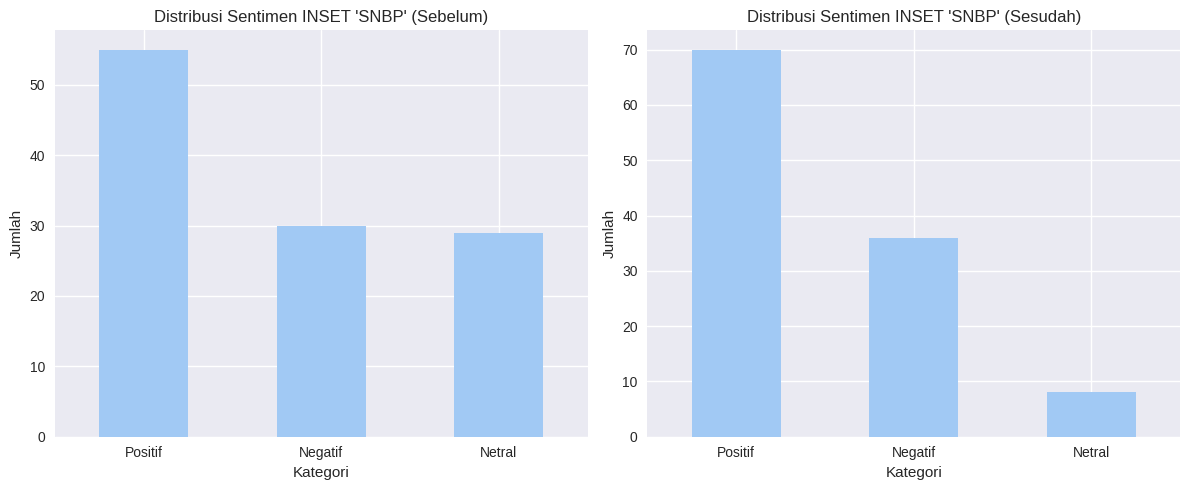

In [ ]:
# @title Visualisasi INSET
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# sentiment BEFORE preprocessing
plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st plot
df['label_inset_before'].value_counts().plot(kind='bar')
plt.title("Distribusi Sentimen INSET 'SNBP' (Sebelum)")
plt.xlabel("Kategori")
plt.ylabel("Jumlah")
plt.xticks(rotation=0)

# sentiment AFTER preprocessing
plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd plot
df['label_inset_after'].value_counts().plot(kind='bar')
plt.title("Distribusi Sentimen INSET 'SNBP' (Sesudah)")
plt.xlabel("Kategori")
plt.ylabel("Jumlah")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

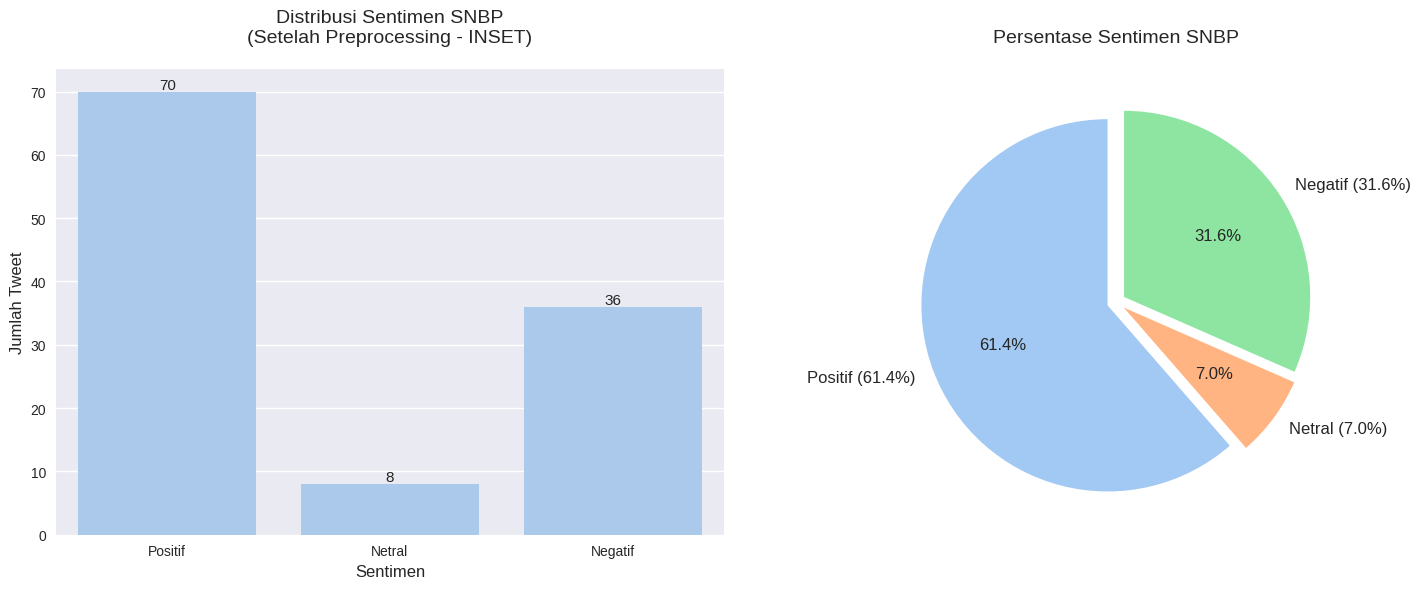

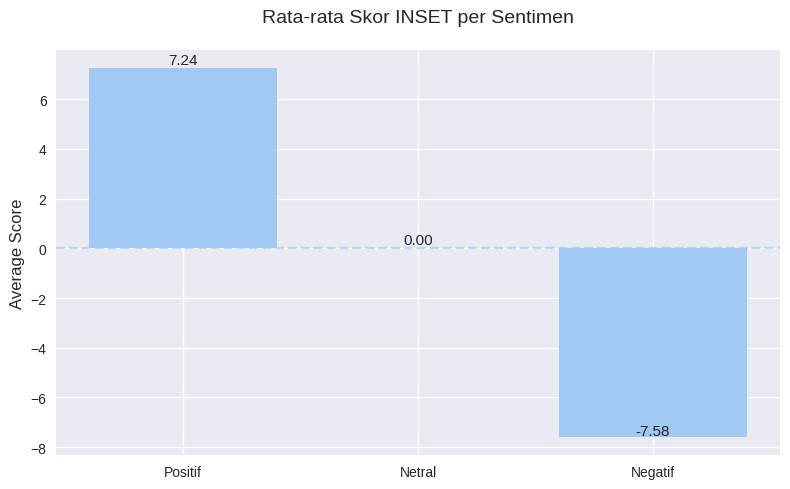

Visualisasi berhasil dibuat!


In [ ]:
# @title Visualisasi INSET
import seaborn as sns
import matplotlib.pyplot as plt

# Style
plt.style.use('seaborn-v0_8')
sns.set_palette("pastel")

# ================== BAR + PIE ==================
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ---------- BAR CHART ----------
sns.countplot(
    data=df,
    x='label_inset_after',
    order=['Positif','Netral','Negatif'],
    ax=axes[0]
)

axes[0].set_title(
    'Distribusi Sentimen SNBP\n(Setelah Preprocessing - INSET)',
    fontsize=14,
    pad=20
)

axes[0].set_xlabel('Sentimen', fontsize=12)
axes[0].set_ylabel('Jumlah Tweet', fontsize=12)

# Label angka di atas bar
for container in axes[0].containers:
    axes[0].bar_label(container, fontsize=11)

# ---------- PIE CHART (DINAMIS, BUKAN HARDCODE) ----------
counts = df['label_inset_after'].value_counts().reindex(
    ['Positif','Netral','Negatif']
)

axes[1].pie(
    counts,
    labels=[f"{label} ({(val/sum(counts)*100):.1f}%)" for label, val in counts.items()],
    autopct='%1.1f%%',
    startangle=90,
    explode=[0.05, 0.05, 0.05],
    textprops={'fontsize': 12}
)

axes[1].set_title(
    'Persentase Sentimen SNBP',
    fontsize=14,
    pad=20
)

plt.tight_layout()
plt.show()

# ================== AVERAGE SCORE ==================
plt.figure(figsize=(8, 5))

avg_score = df.groupby('label_inset_after')['inset_after'].mean().reindex(
    ['Positif','Netral','Negatif']
)

bars = plt.bar(avg_score.index, avg_score.values)

plt.title('Rata-rata Skor INSET per Sentimen', fontsize=14, pad=20)
plt.ylabel('Average Score', fontsize=12)

# Garis nol
plt.axhline(y=0, linestyle='--', alpha=0.7)

# Label angka
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + (0.05 if height >= 0 else -0.05),
        f'{height:.2f}',
        ha='center',
        va='bottom',
        fontsize=11
    )

plt.tight_layout()
plt.show()

print("Visualisasi berhasil dibuat!")

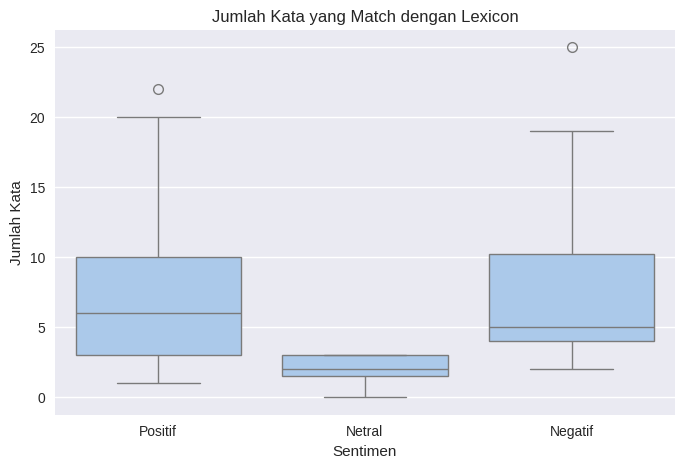

In [ ]:
# @title Analisis Lexicon Match

def count_lexicon_matches(text):
    return sum(
        1 for word in str(text).split()
        if word in positive_words or word in negative_words
    )

df['lexicon_match_count'] = df['clean_text'].apply(count_lexicon_matches)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='label_inset_after',
    y='lexicon_match_count',
    order=['Positif','Netral','Negatif']
)

plt.title('Jumlah Kata yang Match dengan Lexicon')
plt.xlabel('Sentimen')
plt.ylabel('Jumlah Kata')

plt.show()

Hasil Sentimen (VADER vs INSET):


,full_text,label_vader_after,label_inset_after
0,Alhamdulillah ya Allah aku lulus SNBP https://...,Netral,Positif
1,Sch! TOLONGG KASIH TIPS BELAJAR UTBK DARI 0 DI...,Positif,Negatif
2,tahun lalu aku juga dapet merah di SNBP 2025 t...,Netral,Positif
3,adek adek snbp unpad 2026 kalo pengumumannya d...,Negatif,Negatif
4,️ dari SD OSN gagal terus ️ gagal lomba yang l...,Netral,Negatif



Distribusi VADER:
label_vader_after
Netral     89
Positif    15
Negatif    10
Name: count, dtype: int64

Distribusi INSET:
label_inset_after
Positif    70
Negatif    36
Netral      8
Name: count, dtype: int64

Perbandingan VADER vs INSET:
label_inset_after  Negatif  Netral  Positif
label_vader_after                          
Negatif                  1       0        9
Netral                  34       8       47
Positif                  1       0       14


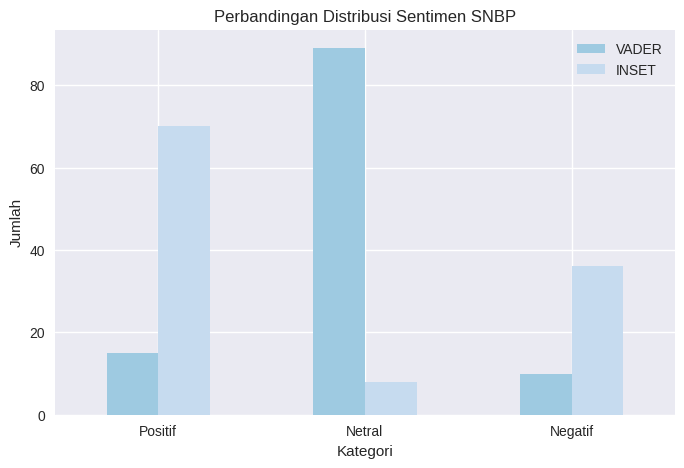

In [ ]:
# @title Perbandingan Sentimen VADER vs INSET

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ================== PREVIEW DATA ==================
print("Hasil Sentimen (VADER vs INSET):")
display(df[['full_text','label_vader_after','label_inset_after']].head(5))

# ================== DISTRIBUSI ==================
print("\nDistribusi VADER:")
print(df['label_vader_after'].value_counts())

print("\nDistribusi INSET:")
print(df['label_inset_after'].value_counts())

# ================== PERBANDINGAN (CROSSTAB) ==================
comparison = pd.crosstab(
    df['label_vader_after'],      # VADER
    df['label_inset_after']       # INSET
)

print("\nPerbandingan VADER vs INSET:")
print(comparison)

# ================== BAR CHART ==================
df_bar = pd.DataFrame({
    'VADER': df['label_vader_after'].value_counts(),
    'INSET': df['label_inset_after'].value_counts()
}).fillna(0)

df_bar = df_bar.reindex(['Positif','Netral','Negatif'])
df_bar.plot(kind='bar', figsize=(8,5), color=['#9ecae1','#c6dbef'])

plt.title('Perbandingan Distribusi Sentimen SNBP')
plt.xlabel('Kategori')
plt.ylabel('Jumlah')
plt.xticks(rotation=0)

plt.show()

In [ ]:
# @title Ekstraksi Fitur - (TF-IDF) : Implementasi Matriks

import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer

# Dataset Preprocessing =====
data = {
    'text': df['clean_text']
}

df_tfidf_input = pd.DataFrame(data)

# TF-IDF =====
vectorizer = TfidfVectorizer()
X_tfidf = vectorizer.fit_transform(df_tfidf_input['text'])

# DataFrame =====
df_tfidf = pd.DataFrame(
    X_tfidf.toarray(),
    columns=vectorizer.get_feature_names_out())

# ===== OUTPUT 1: Matriks fitur
print("=== Matriks TF-IDF SNBP ===")
print(df_tfidf.round(3))

=== Matriks TF-IDF SNBP ===
     aamiin  aamiiniiinn  abangnya    ada  adalah   adek  adekku  adekmu  \
0       0.0        0.000       0.0  0.000     0.0  0.000     0.0     0.0   
1       0.0        0.000       0.0  0.000     0.0  0.000     0.0     0.0   
2       0.0        0.000       0.0  0.131     0.0  0.000     0.0     0.0   
3       0.0        0.000       0.0  0.000     0.0  0.546     0.0     0.0   
4       0.0        0.000       0.0  0.000     0.0  0.000     0.0     0.0   
..      ...          ...       ...    ...     ...    ...     ...     ...   
109     0.0        0.208       0.0  0.000     0.0  0.000     0.0     0.0   
110     0.0        0.000       0.0  0.000     0.0  0.000     0.0     0.0   
111     0.0        0.000       0.0  0.000     0.0  0.000     0.0     0.0   
112     0.0        0.000       0.0  0.000     0.0  0.000     0.0     0.0   
113     0.0        0.000       0.0  0.000     0.0  0.000     0.0     0.0   

     adik  adrian  ...     ya  yaa  yaallah  yakin   yang  

In [ ]:
df_tfidf.head()

,aamiin,aamiiniiinn,abangnya,ada,adalah,adek,adekku,adekmu,adik,adrian,...,ya,yaa,yaallah,yakin,yang,yaudah,years,yg,yh,you
0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.359444,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.131261,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.213712,0.0,0.0,0.0,0.213712,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.000000,0.0,0.546039,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.124402,0.0,0.0,0.0,0.0,0.0


In [ ]:
# @title Analisis Kata Penting (TF-IDF)

# Scoring =====
scores = np.sum(X_tfidf.toarray(), axis=0)

tfidf_scores = pd.DataFrame({
    'kata': vectorizer.get_feature_names_out(),
    'score': scores
}).sort_values(by='score', ascending=False)

# ===== OUTPUT 2
print("=== Top Kata Penting SNBP ===")
print(tfidf_scores.head(10))

=== Top Kata Penting SNBP ===
      kata     score
745   snbp  8.268393
457  lolos  6.116735
21     aku  5.806536
889     ya  4.781713
187     di  4.614044
893   yang  3.970868
330    ini  3.902271
28   allah  3.165062
347   jadi  2.629556
896     yg  2.580591


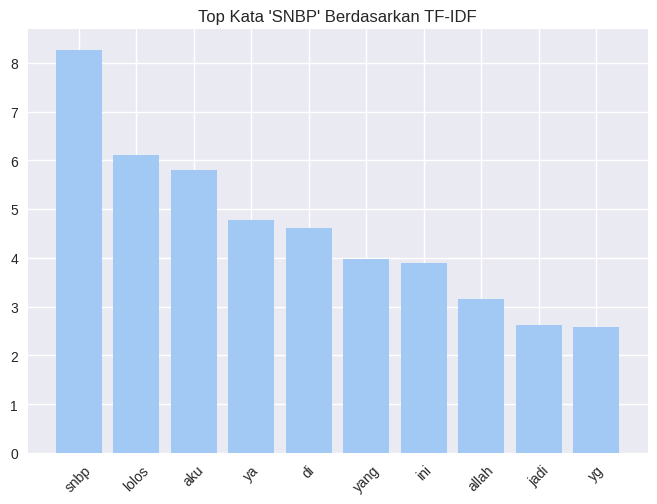

In [ ]:
# @title Visualisasi TF-IDF (Bar Chart)
import matplotlib.pyplot as plt

# Top 10 kata =====
top_words = tfidf_scores.head(10)

plt.figure()
plt.bar(top_words['kata'], top_words['score'])
plt.title("Top Kata 'SNBP' Berdasarkan TF-IDF")
plt.xticks(rotation=45)
plt.show()

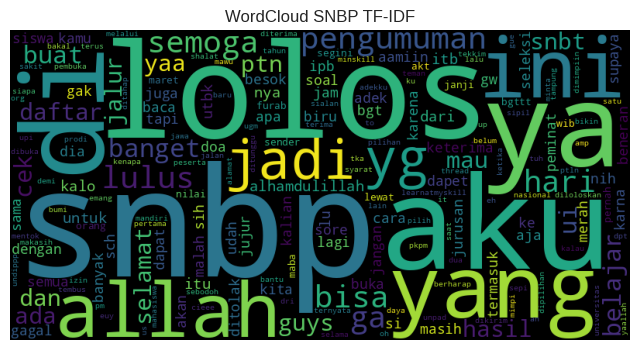

In [ ]:
# @title Visualisasi TF-IDF (WordCloud)
from wordcloud import WordCloud

# Dict =====
word_scores = dict(zip(tfidf_scores['kata'], tfidf_scores['score']))
wordcloud = WordCloud(width=800, height=400).generate_from_frequencies(word_scores)

plt.figure()
plt.imshow(wordcloud)
plt.axis("off")
plt.title("WordCloud SNBP TF-IDF")
plt.show()

In [ ]:
# @title Ekstraksi Fitur - BAG OF WORDS (BoW) : Implementasi
import pandas as pd

# df = pd.read_csv("/content/snbp_preprocessed.csv") # This line is removed to use the preprocessed df in memory
print(df.head())

   conversation_id_str                      created_at  favorite_count  \
0  2038891259851624874  Tue Mar 31 08:08:51 +0000 2026            7251   
1  2038907937909813573  Tue Mar 31 09:15:08 +0000 2026            6155   
2  2038900509667672248  Tue Mar 31 08:45:37 +0000 2026            7995   
3  2038831758125478317  Tue Mar 31 04:12:25 +0000 2026           12911   
4  2038913740226388414  Tue Mar 31 09:38:11 +0000 2026            4914   

                                           full_text               id_str  \
0  Alhamdulillah ya Allah aku lulus SNBP https://...  2038891259851624874   
1  Sch! TOLONGG KASIH TIPS BELAJAR UTBK DARI 0 DI...  2038907937909813573   
2  tahun lalu aku juga dapet merah di SNBP 2025 t...  2038900509667672248   
3  adek adek snbp unpad 2026 kalo pengumumannya d...  2038831758125478317   
4  ️ dari SD OSN gagal terus ️ gagal lomba yang l...  2038913740226388414   

                                         image_url in_reply_to_screen_name  \
0  https://pbs

In [ ]:
bow_df.head()

,aamiin,aamiiniiinn,abangnya,ada,adalah,adek,adekku,adekmu,adik,adrian,...,ya,yaa,yaallah,yakin,yang,yaudah,years,yg,yh,you
0,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,1,0,0,0,0,0,0,...,2,0,0,0,2,0,0,0,0,0
3,0,0,0,0,0,2,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer()
X_bow = vectorizer.fit_transform(df['clean_text'])

bow_df = pd.DataFrame(X_bow.toarray(),
columns=vectorizer.get_feature_names_out())
print(bow_df.head())

   aamiin  aamiiniiinn  abangnya  ada  adalah  adek  adekku  adekmu  adik  \
0       0            0         0    0       0     0       0       0     0   
1       0            0         0    0       0     0       0       0     0   
2       0            0         0    1       0     0       0       0     0   
3       0            0         0    0       0     2       0       0     0   
4       0            0         0    0       0     0       0       0     0   

   adrian  ...  ya  yaa  yaallah  yakin  yang  yaudah  years  yg  yh  you  
0       0  ...   1    0        0      0     0       0      0   0   0    0  
1       0  ...   0    0        0      0     0       0      0   0   0    0  
2       0  ...   2    0        0      0     2       0      0   0   0    0  
3       0  ...   0    0        0      0     0       0      0   0   0    0  
4       0  ...   0    0        0      0     1       0      0   0   0    0  

[5 rows x 899 columns]


In [ ]:
# @title Analysis WORD2VEC
import pandas as pd
from gensim.models import Word2Vec

# ===== Dataset Preprocessing
data = {
    'text': df['clean_text']}

df_w2v = pd.DataFrame(data)

# ===== Tokenisasi List
sentences = [text.split() for text in df_w2v['text']]

# ===== Model Word2Vec
model = Word2Vec(sentences, vector_size=100, window=5,
                min_count=1, workers=1, epochs=100)

# ===== Vektor
print("\n=== Vektor kata 'snbp' ===")
print(model.wv['snbp'])

# ===== Kata-kata yang mirip dengan 'snbp'
print("\n=== Kata mirip dengan 'snbp' ===")
for word, score in model.wv.most_similar('snbp'):
    print(f"{word} (similarity: {score:.3f})")

# ===== Kemiripan antar dua kata
similarity = model.wv.similarity('snbp', 'nilai')
print(f"\nSimilarity antara 'snbp' dan 'nilai': {similarity:.3f}")


=== Vektor kata 'snbp' ===
[-2.25692227e-01  4.16897565e-01  1.01205796e-01  1.11643925e-01
  1.55001879e-01 -6.63471818e-01  1.96132094e-01  8.08139861e-01
 -3.98190141e-01 -2.39654347e-01 -2.82510757e-01 -4.29294318e-01
 -8.84456839e-03  7.73333833e-02  2.54892737e-01 -2.28708267e-01
  2.00830251e-01 -2.05729663e-01 -9.58378315e-02 -8.00746799e-01
  3.54015023e-01  4.98894490e-02  1.47900522e-01 -1.37582183e-01
 -1.18192792e-01  4.05705459e-02 -4.25937682e-01 -1.70875221e-01
 -2.01598331e-01 -7.24467412e-02  3.96390319e-01 -4.80882972e-02
  1.93360969e-01 -3.34910691e-01 -1.51204064e-01  3.69256407e-01
  7.77722672e-02 -2.16914222e-01 -2.28188887e-01 -4.74844426e-01
 -5.34291603e-02 -1.97736233e-01 -1.02872699e-01 -1.43773884e-01
  2.45084301e-01 -1.32262230e-01 -2.36442104e-01  5.06872050e-02
  2.86650985e-01  2.80248851e-01  9.02436823e-02 -2.12888777e-01
 -1.13628268e-01 -1.61655489e-02 -1.50946692e-01  1.92440778e-01
  2.47766241e-01  2.70974357e-02 -4.23193991e-01  1.05398655e-

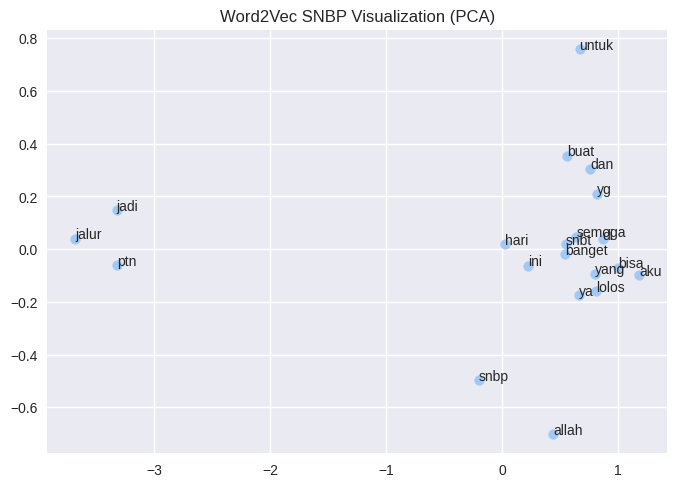

In [ ]:
# @title Word2Vec - Visualisasi
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

words = list(model.wv.index_to_key)[:20]
vectors = model.wv[words]

pca = PCA(n_components=2)
result = pca.fit_transform(vectors)

plt.figure()
plt.scatter(result[:, 0], result[:, 1])

for i, word in enumerate(words):
    plt.annotate(word, (result[i, 0], result[i, 1]))

plt.title("Word2Vec SNBP Visualization (PCA)")
plt.show()